# VeriFact — Análise de Resultados
Visualização dos veredictos gerados pelo LLM-as-a-Judge com Azure OpenAI (GPT-4o-mini).

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

RESULTS_DIR = Path('../data/verifact_results/results/score_reports')
VERDICT_COLORS = {'Supported': '#2ecc71', 'Not Supported': '#e74c3c', 'Not Addressed': '#95a5a6'}

verdicts = pd.read_feather(RESULTS_DIR / 'verdicts.feather')
score_reports = pd.read_feather(RESULTS_DIR / 'score_reports.feather')

print(f'Total de veredictos: {len(verdicts)}')
print(f'Total de score reports: {len(score_reports)}')
verdicts.head(3)

Total de veredictos: 48
Total de score reports: 2


,rater_name,filename,subject_id,author_type,proposition_type,fact_type,retrieval_method,top_n,reference_format,reference_only_admission,deduplicate_text,verdict,reason,reasoning_chain,reasoning_final_answer,text,reference
proposition_id,,,,,,,,,,,,,,,,,
69627667-4382-3279-bb60-b97f85a1d2a5,"fact_type=claim,retrieval_method=hybrid,top_n=10,reference_format=relative_time,reference_only_admission=False,dedup...","subject_id=1084,author_type=llm,proposition_type=claim,fact_type=claim,retrieval_method=hybrid,top_n=10,reference_fo...",1084,llm,claim,claim,hybrid,10,relative time,False,True,Supported,"The reference notes multiple plans and attempts to wean the patient off sedation and ventilator settings, including ...",,,Attempts were made to wean the patient off sedation and ventilator settings after stabilization.,Hospital Admission Start: 1 days 18 hours ago\nHospital Admission End: Now\nElectronic Health Record Context\nOrdere...
875d2a13-ad93-08ab-dbb4-f831f384d920,"fact_type=claim,retrieval_method=hybrid,top_n=10,reference_format=relative_time,reference_only_admission=False,dedup...","subject_id=1084,author_type=llm,proposition_type=claim,fact_type=claim,retrieval_method=hybrid,top_n=10,reference_fo...",1084,llm,claim,claim,hybrid,10,relative time,False,True,Not Supported,"The reference indicates the patient self-extubated on the morning of the second hospital day, not that the patient w...",,,The patient was eventually extubated on the second hospital day.,Hospital Admission Start: 1 days 18 hours ago\nHospital Admission End: Now\nElectronic Health Record Context\nOrdere...
f71ff916-549e-ae7d-b80c-694aea35c843,"fact_type=claim,retrieval_method=hybrid,top_n=10,reference_format=relative_time,reference_only_admission=False,dedup...","subject_id=1084,author_type=llm,proposition_type=claim,fact_type=claim,retrieval_method=hybrid,top_n=10,reference_fo...",1084,llm,claim,claim,hybrid,10,relative time,False,True,Supported,"The reference notes multiple times that the patient is doing well after extubation and appears comfortable, indicati...",,,The patient's condition improved following extubation.,Hospital Admission Start: 1 days 18 hours ago\nHospital Admission End: Now\nElectronic Health Record Context\nOrdere...


## 1. Visão Geral das Proposições

In [14]:
summary = verdicts.groupby('reference_only_admission').agg(
    total_propositions=('verdict', 'count'),
    unique_propositions=('text', 'nunique'),
    supported=('verdict', lambda x: (x == 'Supported').sum()),
    not_supported=('verdict', lambda x: (x == 'Not Supported').sum()),
    not_addressed=('verdict', lambda x: (x == 'Not Addressed').sum()),
).reset_index()
summary['reference_only_admission'] = summary['reference_only_admission'].map(
    {True: 'So Admissao', False: 'EHR Completo'}
)
summary

,reference_only_admission,total_propositions,unique_propositions,supported,not_supported,not_addressed
0,EHR Completo,24,24,15,8,1
1,So Admissao,24,24,15,9,0


## 2. Distribuição de Veredictos

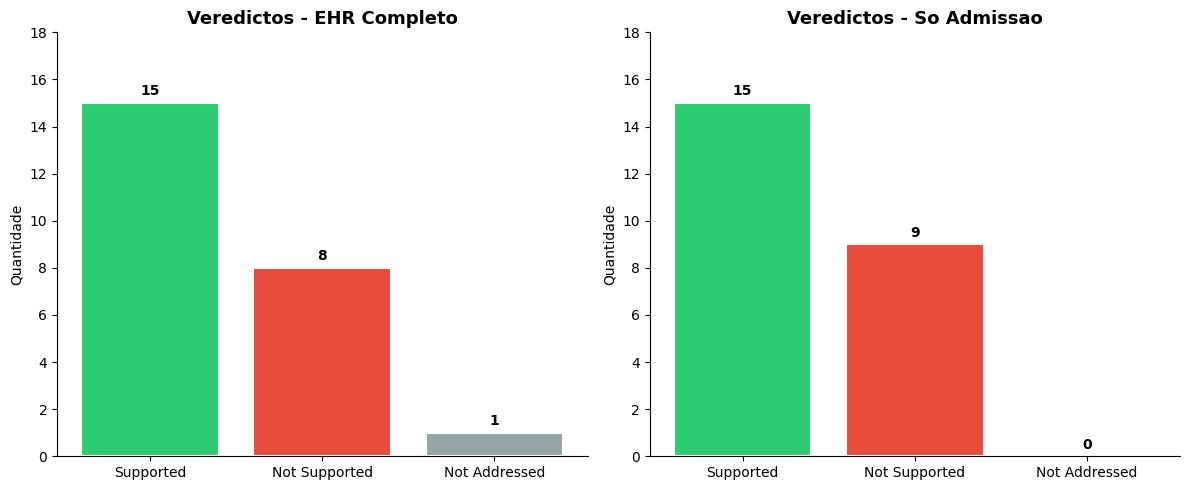

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (ref_only, label) in zip(axes, [(False, 'EHR Completo'), (True, 'So Admissao')]):
    subset = verdicts[verdicts.reference_only_admission == ref_only]
    counts = subset['verdict'].value_counts().reindex(VERDICT_COLORS.keys(), fill_value=0)
    bars = ax.bar(counts.index, counts.values, color=[VERDICT_COLORS[v] for v in counts.index], edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2, str(val), ha='center', va='bottom', fontweight='bold')
    ax.set_title(f'Veredictos - {label}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Quantidade')
    ax.set_ylim(0, counts.max() + 3)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

## 3. Proporção de Veredictos (Pizza)

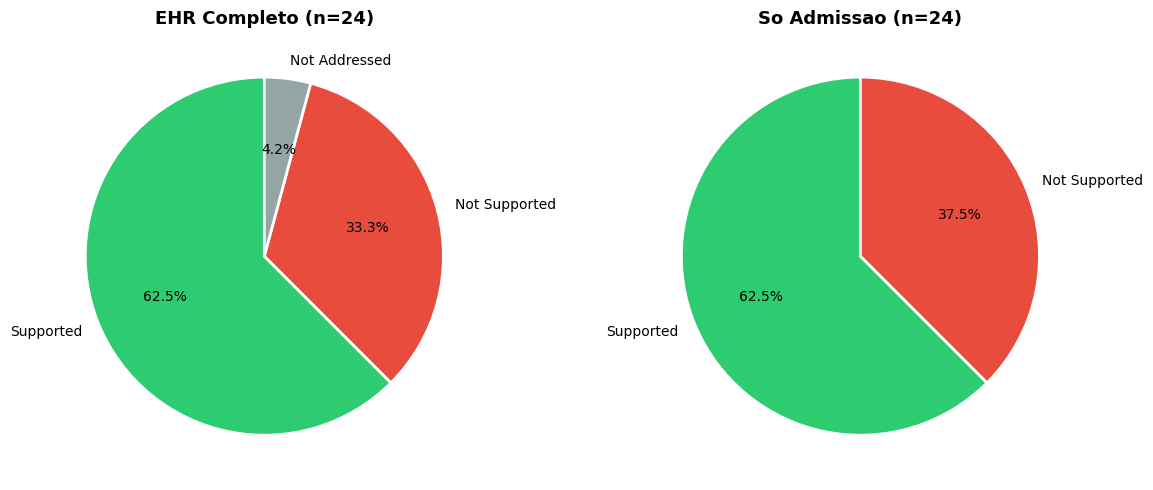

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (ref_only, label) in zip(axes, [(False, 'EHR Completo'), (True, 'So Admissao')]):
    subset = verdicts[verdicts.reference_only_admission == ref_only]
    counts = subset['verdict'].value_counts().reindex(VERDICT_COLORS.keys(), fill_value=0)
    counts = counts[counts > 0]
    ax.pie(
        counts.values,
        labels=counts.index,
        colors=[VERDICT_COLORS[v] for v in counts.index],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    )
    ax.set_title(f'{label} (n={len(subset)})', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Comparação: EHR Completo vs Só Admissão

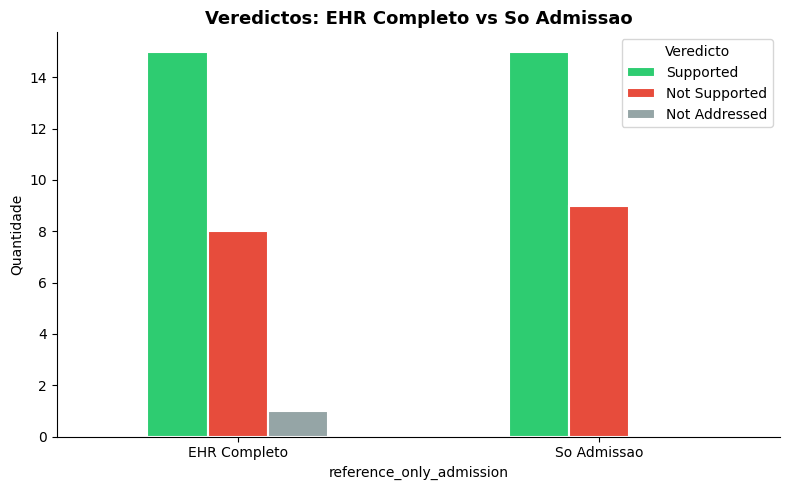

In [17]:
pivot = verdicts.groupby(['reference_only_admission', 'verdict']).size().unstack(fill_value=0)
pivot.index = pivot.index.map({True: 'So Admissao', False: 'EHR Completo'})
pivot = pivot.reindex(columns=[c for c in VERDICT_COLORS if c in pivot.columns])

ax = pivot.plot(
    kind='bar',
    color=[VERDICT_COLORS[c] for c in pivot.columns],
    figsize=(8, 5),
    edgecolor='white',
    linewidth=1.5,
    rot=0,
)
ax.set_title('Veredictos: EHR Completo vs So Admissao', fontsize=13, fontweight='bold')
ax.set_ylabel('Quantidade')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend(title='Veredicto')
sns.despine()
plt.tight_layout()
plt.show()

## 5. Score Report — Scores Agregados

In [18]:
score_cols = ['supported_score', 'not_supported_score', 'not_addressed_score',
              'supported_count', 'not_supported_count', 'not_addressed_count', 'total_count']
df_scores = score_reports[['subject_id', 'reference_only_admission'] + score_cols].copy()
df_scores['reference_only_admission'] = df_scores['reference_only_admission'].map(
    {True: 'So Admissao', False: 'EHR Completo'}
)
df_scores.style \
    .format({'supported_score': '{:.1%}', 'not_supported_score': '{:.1%}', 'not_addressed_score': '{:.1%}'}) \
    .background_gradient(subset=['supported_score'], cmap='Greens') \
    .background_gradient(subset=['not_supported_score'], cmap='Reds')

,subject_id,reference_only_admission,supported_score,not_supported_score,not_addressed_score,supported_count,not_supported_count,not_addressed_count,total_count
0,1084,EHR Completo,62.5%,33.3%,4.2%,15,8,1,24
1,1084,So Admissao,62.5%,37.5%,0.0%,15,9,0,24


## 6. Matriz de Classificação (EHR Completo vs Só Admissão)

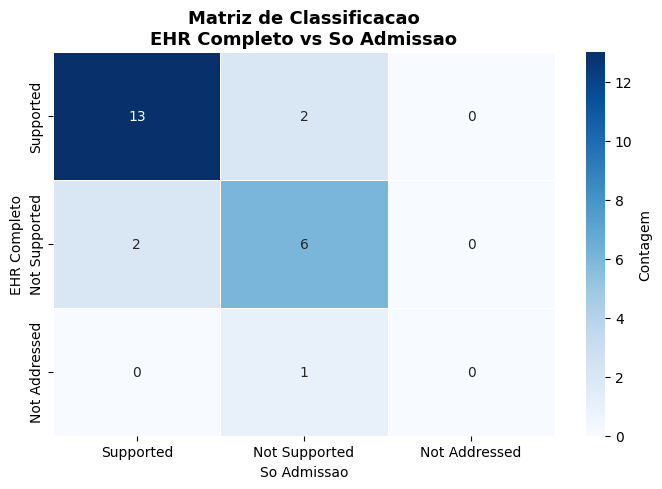

Concordancia entre configuracoes:
  79.2% (19/24 proposicoes)


In [19]:
pivot_verdicts = verdicts.pivot_table(
    index='proposition_id',
    columns='reference_only_admission',
    values='verdict',
    aggfunc='first'
).rename(columns={False: 'EHR Completo', True: 'So Admissao'})

label_order = ['Supported', 'Not Supported', 'Not Addressed']
confusion = pd.crosstab(
    pivot_verdicts['EHR Completo'],
    pivot_verdicts['So Admissao'],
    rownames=['EHR Completo'],
    colnames=['So Admissao']
).reindex(index=label_order, columns=label_order, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    confusion, annot=True, fmt='d', cmap='Blues',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Contagem'},
    ax=ax
)
ax.set_title('Matriz de Classificacao\nEHR Completo vs So Admissao', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Concordancia entre configuracoes:')
agreement = (pivot_verdicts['EHR Completo'] == pivot_verdicts['So Admissao']).mean()
print(f'  {agreement:.1%} ({int(agreement * len(pivot_verdicts))}/{len(pivot_verdicts)} proposicoes)')

## 7. Proposições com Veredictos Divergentes

In [23]:
divergent = pivot_verdicts[pivot_verdicts['EHR Completo'] != pivot_verdicts['So Admissao']].copy()
# divergent['text'] = verdicts.drop_duplicates('proposition_id').set_index('proposition_id')['text']

print(f'Proposicoes com veredictos divergentes: {len(divergent)}')
# pd.set_option('display.max_colwidth', 100)
# divergent[['text', 'EHR Completo', 'So Admissao']]

Proposicoes com veredictos divergentes: 5


## 8. Tabela Detalhada de Veredictos por Proposição

In [21]:
pd.set_option('display.max_colwidth', 120)

for ref_only, label in [(False, 'EHR Completo'), (True, 'So Admissao')]:
    print(f'\n{"="*80}')
    print(f'  {label}')
    print(f'{"="*80}')
    subset = verdicts[verdicts.reference_only_admission == ref_only][['text', 'verdict', 'reason']].copy()
    subset.index = range(1, len(subset) + 1)
    display(subset.style.apply(
        lambda row: ['', f'background-color: {VERDICT_COLORS.get(row.verdict, "white")}33; font-weight: bold', ''],
        axis=1
    ))


  EHR Completo


,text,verdict,reason
1,Attempts were made to wean the patient off sedation and ventilator settings after stabilization.,Supported,"The reference notes multiple plans and attempts to wean the patient off sedation and ventilator settings, including a nursing note describing an attempt to wean sedation and physician notes about plans to wean for extubation."
2,The patient was eventually extubated on the second hospital day.,Not Supported,"The reference indicates the patient self-extubated on the morning of the second hospital day, not that the patient was extubated as planned or by medical staff on that day."
3,The patient's condition improved following extubation.,Supported,"The reference notes multiple times that the patient is doing well after extubation and appears comfortable, indicating improvement following extubation."
4,The patient had taken Ambien instead of his prescribed methadone.,Supported,"The nursing note explicitly states that the patient took Ambien instead of his methadone yesterday afternoon, directly supporting the text."
5,Taking Ambien instead of methadone led to the patient's altered mental state.,Not Supported,The reference notes the patient took Ambien instead of methadone but does not explicitly link this substitution to the altered mental state; altered mental status is also associated with Narcan administration.
6,The patient was admitted to the ICU with altered mental status (AMS).,Not Supported,"The reference indicates the patient had altered mental status at home and was transferred to the ICU intubated, but it does not explicitly state that the patient was admitted to the ICU with altered mental status."
7,The patient was admitted to the ICU with agitation.,Supported,"The reference states the patient was agitated upon arrival and was receiving ICU care, supporting that the patient was admitted to the ICU with agitation."
8,The patient was admitted to the ICU with a urinary tract infection (UTI).,Not Supported,The reference confirms the patient has a urinary tract infection but does not specify that the patient was admitted to the ICU.
9,The patient was intubated due to agitated behavior.,Supported,"The reference states multiple times that the patient was intubated due to agitation or agitated behavior, directly supporting the text."
10,The patient was sedated due to agitated behavior.,Supported,"The reference notes indicate the patient was agitated and subsequently sedated, including being sedated on propofol and intubated, supporting that sedation was due to agitated behavior."



  So Admissao


,text,verdict,reason
1,Attempts were made to wean the patient off sedation and ventilator settings after stabilization.,Supported,"The reference notes multiple plans and attempts to wean the patient off sedation and ventilator settings, including a nursing note stating an attempt was made to wean sedation after stabilization."
2,The patient was eventually extubated on the second hospital day.,Not Supported,"The reference indicates the patient self-extubated on the morning of the second hospital day, not that the patient was extubated by medical staff as implied by 'eventually extubated.'"
3,The patient's condition improved following extubation.,Not Supported,"The reference notes that after extubation, the patient was disoriented and very confused, which does not indicate improvement following extubation."
4,The patient had taken Ambien instead of his prescribed methadone.,Supported,"The reference states that the patient took Ambien instead of his methadone yesterday afternoon, directly supporting the text."
5,Taking Ambien instead of methadone led to the patient's altered mental state.,Supported,"The reference states that the patient took Ambien instead of methadone yesterday afternoon and has altered mental status, supporting the text that taking Ambien instead of methadone led to the altered mental state."
6,The patient was admitted to the ICU with altered mental status (AMS).,Not Supported,"The reference indicates the patient had altered mental status at home and was transferred to the ICU intubated, but it does not explicitly state that the patient was admitted to the ICU with altered mental status."
7,The patient was admitted to the ICU with agitation.,Not Supported,"The reference indicates the patient was agitated upon arrival and received ICU care, but it does not state that the patient was admitted to the ICU with agitation; the agitation occurred prior to or during emergency department care and intubation, not explicitly at ICU admission."
8,The patient was admitted to the ICU with a urinary tract infection (UTI).,Not Supported,The reference confirms the patient has a urinary tract infection but does not specify that the patient was admitted to the ICU.
9,The patient was intubated due to agitated behavior.,Supported,"The reference states multiple times that the patient was intubated due to agitation or agitated behavior, confirming the text."
10,The patient was sedated due to agitated behavior.,Supported,"The reference notes that the patient was agitated and subsequently sedated, including being sedated on propofol and transferred sedated to the ICU, supporting that sedation was due to agitated behavior."


## 9. Comparação com Ground Truth Humano (Confusion Matrix + Gwet's AC1)

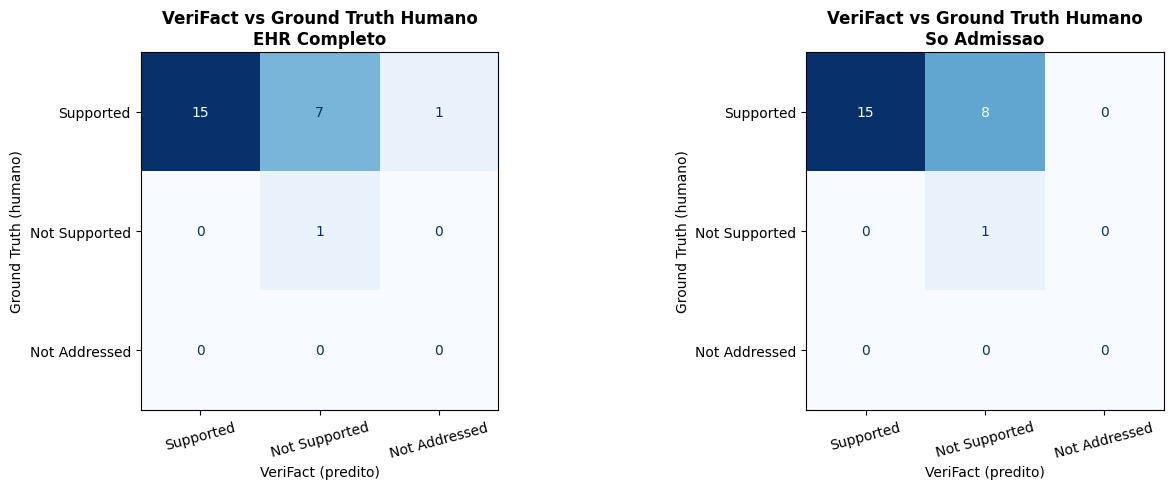


=== EHR Completo (n=24) ===
               precision    recall  f1-score   support

    Supported       1.00      0.65      0.79        23
Not Supported       0.12      1.00      0.22         1
Not Addressed       0.00      0.00      0.00         0

     accuracy                           0.67        24
    macro avg       0.38      0.55      0.34        24
 weighted avg       0.96      0.67      0.77        24

Gwet's AC1 = 0.5990  (IC95% 0.3262 - 0.8717)   p = 1.5e-04

=== So Admissao (n=24) ===
               precision    recall  f1-score   support

    Supported       1.00      0.65      0.79        23
Not Supported       0.11      1.00      0.20         1
Not Addressed       0.00      0.00      0.00         0

     accuracy                           0.67        24
    macro avg       0.37      0.55      0.33        24
 weighted avg       0.96      0.67      0.76        24

Gwet's AC1 = 0.6008  (IC95% 0.3315 - 0.8702)   p = 1.2e-04


In [22]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from irrCAC.raw import CAC

# Carregar ground truth
props = pd.read_csv('../data/propositions.csv.gz')
human_verdicts = pd.read_csv('../data/human_verdicts.csv.gz')

# Juntar subject_id ao ground truth e filtrar paciente
gt = human_verdicts.merge(props[['proposition_id', 'subject_id']], on='proposition_id')
gt = gt[gt.subject_id == 1084][['proposition_id', 'human_gt']].set_index('proposition_id')

label_order = ['Supported', 'Not Supported', 'Not Addressed']

# --- Confusion Matrix ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (ref_only, label) in zip(axes, [(False, 'EHR Completo'), (True, 'So Admissao')]):
    subset = verdicts[verdicts.reference_only_admission == ref_only][['verdict']].copy()
    merged = subset.join(gt.rename(columns={'human_gt': 'ground_truth'}), how='inner')

    cm = confusion_matrix(merged['ground_truth'], merged['verdict'], labels=label_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_order)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'VeriFact vs Ground Truth Humano\n{label}', fontsize=12, fontweight='bold')
    ax.set_xlabel('VeriFact (predito)')
    ax.set_ylabel('Ground Truth (humano)')
    for tick in ax.get_xticklabels():
        tick.set_rotation(15)

plt.tight_layout()
plt.show()

# --- Classification Report + Gwet's AC1 ---
for ref_only, label in [(False, 'EHR Completo'), (True, 'So Admissao')]:
    subset = verdicts[verdicts.reference_only_admission == ref_only][['verdict']].copy()
    merged = subset.join(gt.rename(columns={'human_gt': 'ground_truth'}), how='inner')
    print(f'\n=== {label} (n={len(merged)}) ===')
    print(classification_report(merged['ground_truth'], merged['verdict'], labels=label_order, zero_division=0))

    # Gwet's AC1 — DataFrame com 1 coluna por rater
    ratings = pd.DataFrame({'Human': merged['ground_truth'].values, 'VeriFact': merged['verdict'].values})
    ac1 = CAC(ratings, categories=label_order).gwet()
    coef = ac1['est']['coefficient_value']
    lo, hi = ac1['est']['confidence_interval']
    p = ac1['est']['p_value']
    print(f"Gwet's AC1 = {coef:.4f}  (IC95% {lo:.4f} - {hi:.4f})   p = {p:.1e}")

## 10. Contexto de Referência — Exemplos

In [ ]:
icons = {'Supported': 'SUPPORTED', 'Not Supported': 'NOT SUPPORTED', 'Not Addressed': 'NOT ADDRESSED'}
sample = verdicts[verdicts.reference_only_admission == False].head(3)

for _, row in sample.iterrows():
    print(f'[{icons.get(row.verdict, row.verdict)}] {row.text}')
    print(f'  Razao: {row.reason}')
    print(f'  Contexto EHR (primeiras 5 entradas):')
    for line in row.reference.strip().split('\n')[:6]:
        if line.strip():
            print(f'    {line}')
    print()